In [2]:
# ── Cell 1: Imports & Load Results ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay)

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/My Drive/IoT Intrusion Detection/data/'

# Load test data (both versions - RF uses unscaled, NN uses scaled)
X_test_unscaled = pd.read_csv(DATA_PATH + 'X_test.csv')
X_test_scaled   = np.load(DATA_PATH + 'X_test_scaled.npy')
y_test          = np.load(DATA_PATH + 'y_test.npy')

# Load both trained models
rf  = joblib.load(DATA_PATH + 'random_forest_model.pkl')
mlp = joblib.load(DATA_PATH + 'neural_network_model.pkl')

print(f"Test set: {X_test_unscaled.shape}")
print("Models loaded")

Mounted at /content/drive
Test set: (508010, 43)
Models loaded


In [3]:
# ── Cell 2: Predictions ───────────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test_unscaled)
y_pred_mlp = mlp.predict(X_test_scaled)

print("Random Forest predictions")
print("Neural Network predictions")

Random Forest predictions
Neural Network predictions


In [5]:
# ── Cell 3: Build Comparison Table ───────────────────────────────────────────
def compute_metrics(y_true, y_pred, model_name):
    return {
        'Model':            model_name,
        'Accuracy':         accuracy_score(y_true, y_pred),
        'F1 Score':         f1_score(y_true, y_pred),
        'Attack Precision': precision_score(y_true, y_pred),
        'Attack Recall':    recall_score(y_true, y_pred),
        'Normal Precision': precision_score(y_true, y_pred, pos_label=0),
        'Normal Recall':    recall_score(y_true, y_pred, pos_label=0),
    }

comparison_df = pd.DataFrame([
    compute_metrics(y_test, y_pred_rf, 'Random Forest'),
    compute_metrics(y_test, y_pred_mlp, 'Neural Network')
])

# Round for clean display
comparison_df = comparison_df.set_index('Model').round(4)
print("=" * 60)
print("  MODEL COMPARISON TABLE")
print("=" * 60)
display(comparison_df)

# Save the table for the README
comparison_df.to_csv(DATA_PATH + 'final_comparison.csv')
print("\nSaved => final_comparison.csv")

  MODEL COMPARISON TABLE


,Accuracy,F1 Score,Attack Precision,Attack Recall,Normal Precision,Normal Recall
Model,,,,,,
Random Forest,0.9912,0.9663,0.9384,0.9959,0.9994,0.9905
Neural Network,0.9925,0.9699,0.9799,0.9601,0.9942,0.9971



Saved => final_comparison.csv


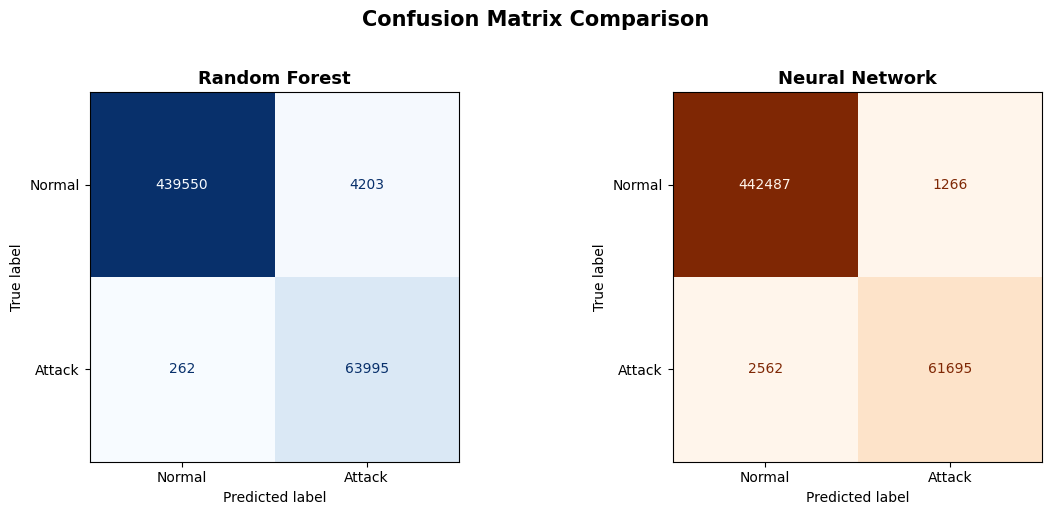

Saved => comparison_confusion_matrices.png


In [6]:
# ── Cell 4: Side-by-Side Confusion Matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

ConfusionMatrixDisplay(cm_rf,  display_labels=['Normal', 'Attack']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(cm_mlp, display_labels=['Normal', 'Attack']).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Neural Network', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_PATH + 'comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved => comparison_confusion_matrices.png")

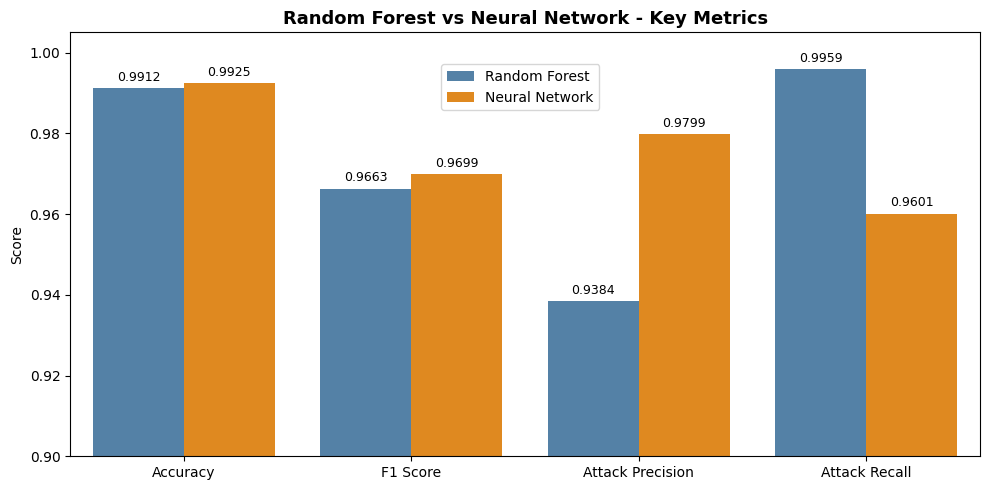

Saved => comparison_bar_chart.png


In [13]:
# ── Cell 5: Bar Chart of Key Metrics ─────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1 Score', 'Attack Precision', 'Attack Recall']
plot_df = comparison_df[metrics_to_plot].reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette=['steelblue', 'darkorange'], ax=ax)

ax.set_title('Random Forest vs Neural Network - Key Metrics',fontsize=13, fontweight='bold')
ax.set_ylim(0.90, 1.005)
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.legend(loc='lower right')
ax.legend(bbox_to_anchor=(0.4, 0.8))

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig(DATA_PATH + 'comparison_bar_chart.png',dpi=150, bbox_inches='tight')
plt.show()
print("Saved => comparison_bar_chart.png")

In [20]:
# ── Cell 6: Trade-off Summary ────────────────────────────────────────────────
rf_missed_attacks = cm_rf[1, 0]
mlp_missed_attacks = cm_mlp[1, 0]
rf_false_alarms = cm_rf[0, 1]
mlp_false_alarms = cm_mlp[0, 1]

print("=" * 60)
print("REAL-WORLD IMPACT")
print("=" * 60)
print(f"\nOut of {y_test.sum():,} actual attacks:")
print(f"  Random Forest missed:  {rf_missed_attacks:>6,}  ({rf_missed_attacks/y_test.sum()*100:.2f}%)")
print(f"  Neural Network missed: {mlp_missed_attacks:>6,}  ({mlp_missed_attacks/y_test.sum()*100:.2f}%)")

print(f"\nOut of {(y_test==0).sum():,} normal connections:")
print(f"  Random Forest false alarms:  {rf_false_alarms:>6,}  ({rf_false_alarms/(y_test==0).sum()*100:.2f}%)")
print(f"  Neural Network false alarms: {mlp_false_alarms:>6,}  ({mlp_false_alarms/(y_test==0).sum()*100:.2f}%)")

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print("""
Both models exceed 99% accuracy, but show a clear trade-off:

  * Random Forest  => near-perfect attack detection (high recall), at the cost of more false alarms
  * Neural Network => fewer false alarms (high precision), but misses more real attacks

For a production IoT IDS, the choice depends on the cost of each error type. In high-stakes environments (critical infrastructure, healthcare IoT), missing an attack is more costly than a false alarm - Random Forest would be preferred.
In low-stakes environments where alert fatigue is a concern, the Neural Network's precision is more valuable.

A hybrid or ensemble approach combining both models is a natural next step.
""")

REAL-WORLD IMPACT

Out of 64,257 actual attacks:
  Random Forest missed:     262  (0.41%)
  Neural Network missed:  2,562  (3.99%)

Out of 443,753 normal connections:
  Random Forest false alarms:   4,203  (0.95%)
  Neural Network false alarms:  1,266  (0.29%)

CONCLUSION

Both models exceed 99% accuracy, but show a clear trade-off:

  * Random Forest  => near-perfect attack detection (high recall), at the cost of more false alarms
  * Neural Network => fewer false alarms (high precision), but misses more real attacks

For a production IoT IDS, the choice depends on the cost of each error type. In high-stakes environments (critical infrastructure, healthcare IoT), missing an attack is more costly than a false alarm - Random Forest would be preferred.
In low-stakes environments where alert fatigue is a concern, the Neural Network's precision is more valuable.

A hybrid or ensemble approach combining both models is a natural next step.



In [27]:
# ── Cell 7: Save Final Summary ───────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':           ['Random Forest', 'Neural Network'],
    'Accuracy (%)':    [accuracy_score(y_test, y_pred_rf)*100, accuracy_score(y_test, y_pred_mlp)*100],
    'F1 Score':        [f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_mlp)],
    'Missed Attacks':  [int(rf_missed_attacks),int(mlp_missed_attacks)],
    'False Alarms':    [int(rf_false_alarms),int(mlp_false_alarms)],
}).round(4)

summary.to_csv(DATA_PATH + 'final_summary.csv', index=False)
print("Final summary saved => final_summary.csv\n")
display(summary)

Final summary saved => final_summary.csv



,Model,Accuracy (%),F1 Score,Missed Attacks,False Alarms
0,Random Forest,99.1211,0.9663,262,4203
1,Neural Network,99.2465,0.9699,2562,1266
